# 📱 Unveiling the Android App Market
## Google Play Store Analysis

### OIBSIP – Level 2 | Task 4

**Author:**  
Zarna Namojwar

# Load Google Play Store Datasets

Two datasets are used in this project:
1. Google Play Store Apps Dataset
2. Google Play Store User Reviews Dataset

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from textblob import TextBlob
import plotly.express as px

# Load datasets
apps_df = pd.read_csv("Googleapps_data.csv")
reviews_df = pd.read_csv("User_Reviews.csv")

print("Apps Dataset Shape:", apps_df.shape)
print("Reviews Dataset Shape:", reviews_df.shape)

Apps Dataset Shape: (9659, 14)
Reviews Dataset Shape: (4321, 2)


In [8]:
apps_df.head()

,Unnamed: 0,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19.0,"10,000+",Free,0,Everyone,Art & Design,07-Jan-18,1.0.0,4.0.3 and up
1,1,Coloring book moana,ART_AND_DESIGN,3.9,967,14.0,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,15-Jan-18,2.0.0,4.0.3 and up
2,2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7,"5,000,000+",Free,0,Everyone,Art & Design,01-Aug-18,1.2.4,4.0.3 and up
3,3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25.0,"50,000,000+",Free,0,Teen,Art & Design,08-Jun-18,Varies with device,4.2 and up
4,4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8,"100,000+",Free,0,Everyone,Art & Design;Creativity,20-Jun-18,1.1,4.4 and up


In [9]:
reviews_df.head()

,review,class
0,Fantastic spot for an even or a quite cocktail...,1
1,"Love, love, love the calamari. It's so good an...",1
2,"Love this place. Stiff martinis and cocktails,...",1
3,It's everything a great cocktail bar should be...,1
4,"I came here before a pirates game, so it was a...",1


# Step 3: Dataset Inspection

Before performing data cleaning, the structure and quality of both datasets are examined.

The analysis includes:
- Dataset information and data types
- Missing values
- Duplicate records
- Basic descriptive statistics

In [11]:
apps_df.info()
reviews_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9659 entries, 0 to 9658
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Unnamed: 0      9659 non-null   int64  
 1   App             9659 non-null   str    
 2   Category        9659 non-null   str    
 3   Rating          8196 non-null   float64
 4   Reviews         9659 non-null   int64  
 5   Size            8432 non-null   float64
 6   Installs        9659 non-null   str    
 7   Type            9659 non-null   str    
 8   Price           9659 non-null   str    
 9   Content Rating  9659 non-null   str    
 10  Genres          9659 non-null   str    
 11  Last Updated    9659 non-null   str    
 12  Current Ver     9651 non-null   str    
 13  Android Ver     9657 non-null   str    
dtypes: float64(2), int64(2), str(10)
memory usage: 1.0 MB
<class 'pandas.DataFrame'>
RangeIndex: 4321 entries, 0 to 4320
Data columns (total 2 columns):
 #   Column  Non-Null Count  D

In [12]:
print("Missing Values in Apps Dataset:")
print(apps_df.isnull().sum())

print("\nMissing Values in Reviews Dataset:")
print(reviews_df.isnull().sum())

Missing Values in Apps Dataset:
Unnamed: 0           0
App                  0
Category             0
Rating            1463
Reviews              0
Size              1227
Installs             0
Type                 0
Price                0
Content Rating       0
Genres               0
Last Updated         0
Current Ver          8
Android Ver          2
dtype: int64

Missing Values in Reviews Dataset:
review    0
class     0
dtype: int64


In [13]:
print("Duplicate rows in Apps Dataset:", apps_df.duplicated().sum())
print("Duplicate rows in Reviews Dataset:", reviews_df.duplicated().sum())

Duplicate rows in Apps Dataset: 0
Duplicate rows in Reviews Dataset: 173


In [14]:
apps_df.describe(include="all")

,Unnamed: 0,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
count,9659.000000,9659,9659,8196.000000,9.659000e+03,8432.000000,9659,9659,9659,9659,9659,9659,9651,9657
unique,NaN,9659,33,NaN,NaN,NaN,21,2,92,6,118,1377,2769,33
top,NaN,Photo Editor & Candy Camera & Grid & ScrapBook,FAMILY,NaN,NaN,NaN,"1,000,000+",Free,0,Everyone,Tools,03-Aug-18,Varies with device,4.1 and up
freq,NaN,1,1832,NaN,NaN,NaN,1417,8903,8903,7903,826,252,1055,2202
mean,5666.172896,NaN,NaN,4.173243,2.165926e+05,20.395327,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,3102.362863,NaN,NaN,0.536625,1.831320e+06,21.827509,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,0.000000,NaN,NaN,1.000000,0.000000e+00,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,3111.500000,NaN,NaN,4.000000,2.500000e+01,4.600000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,5814.000000,NaN,NaN,4.300000,9.670000e+02,12.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,8327.500000,NaN,NaN,4.500000,2.940100e+04,28.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Observation

- The Apps dataset contains missing values in `Rating`, `Size`, `Current Ver`, and `Android Ver`.
- `Rating` has the highest number of missing values (1,463), while `Size` has 1,227 missing values.
- The Apps dataset contains no duplicate records.
- The User Reviews dataset contains 173 duplicate records.
- The User Reviews dataset has no missing values.
- These issues will be handled during the data-cleaning stage before further analysis.

# Step 4: Data Cleaning

The Apps dataset contains missing values and columns stored in unsuitable formats.

The following cleaning steps are performed:
- Fill missing ratings using the median rating.
- Convert app size into numeric values.
- Convert installs into numeric values.
- Convert price into numeric values.
- Remove duplicate app records if present.

In [15]:
#clean Rating
apps_df["Rating"] = apps_df["Rating"].fillna(apps_df["Rating"].median())

In [17]:
#clean size
apps_df["Size"] = apps_df["Size"].astype(str).str.replace("M", "", regex=False)
apps_df["Size"] = apps_df["Size"].str.replace("k", "", regex=False)

apps_df["Size"] = pd.to_numeric(apps_df["Size"], errors="coerce")
apps_df["Size"] = apps_df["Size"].fillna(apps_df["Size"].median())

In [20]:
#clean installs
apps_df["Installs"] = (
    apps_df["Installs"]
    .astype(str)
    .str.replace(",", "", regex=False)
    .str.replace("+", "", regex=False)
)

apps_df["Installs"] = pd.to_numeric(apps_df["Installs"], errors="coerce")

#clean price
apps_df["Price"] = (
    apps_df["Price"]
    .astype(str)
    .str.replace("$", "", regex=False)
)

apps_df["Price"] = pd.to_numeric(apps_df["Price"], errors="coerce")

In [21]:
#remove duplicates
apps_df = apps_df.drop_duplicates(subset="App").reset_index(drop=True)

print("Cleaned Apps Dataset Shape:", apps_df.shape)

Cleaned Apps Dataset Shape: (9659, 14)


# Step 5: App Category Analysis

The distribution of apps across categories is analysed to identify the most saturated categories in the Google Play Store.

In [22]:
category_counts = apps_df["Category"].value_counts()

print("Top 10 App Categories:")
print(category_counts.head(10))

Top 10 App Categories:
Category
FAMILY             1832
GAME                959
TOOLS               827
BUSINESS            420
MEDICAL             395
PERSONALIZATION     376
PRODUCTIVITY        374
LIFESTYLE           369
FINANCE             345
SPORTS              325
Name: count, dtype: int64


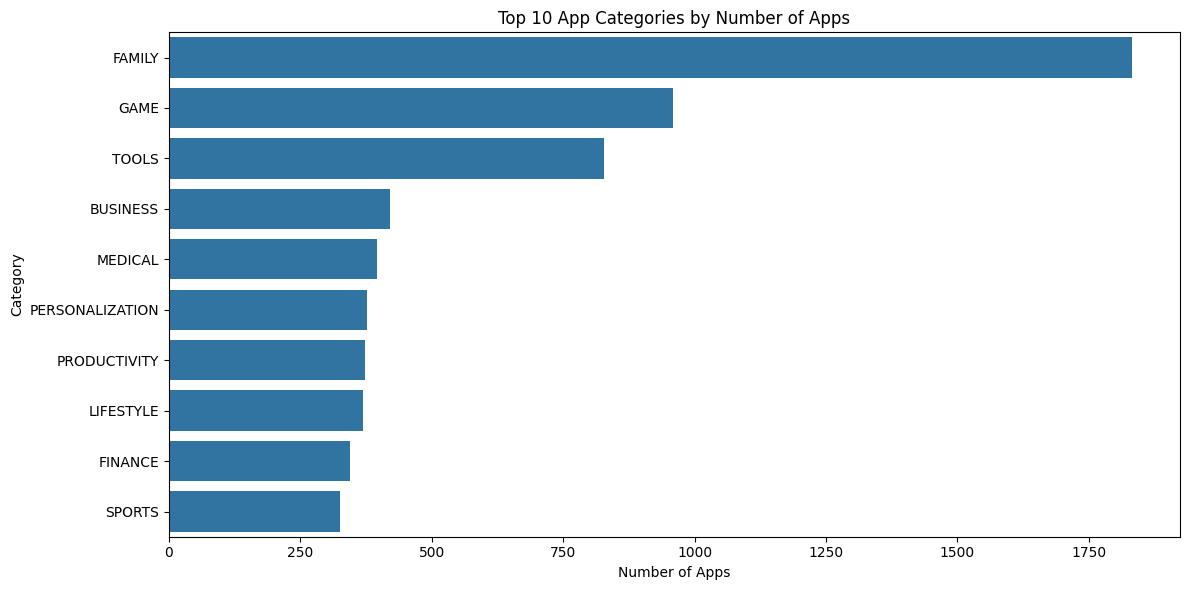

In [23]:
plt.figure(figsize=(12, 6))

sns.barplot(
    x=category_counts.head(10).values,
    y=category_counts.head(10).index
)

plt.title("Top 10 App Categories by Number of Apps")
plt.xlabel("Number of Apps")
plt.ylabel("Category")
plt.tight_layout()
plt.show()

### Observation

- **FAMILY** is the most saturated category, with the highest number of apps.
- **GAME** is the second-largest category, followed by **TOOLS**.
- BUSINESS, MEDICAL, PERSONALIZATION, PRODUCTIVITY, and LIFESTYLE have moderate app representation.
- The high number of apps in FAMILY and GAME indicates strong competition in these categories.
- Developers entering highly saturated categories may need stronger differentiation to stand out.

# Step 6: Ratings Analysis

App ratings are analysed to understand the overall rating distribution and compare average ratings across different app categories.

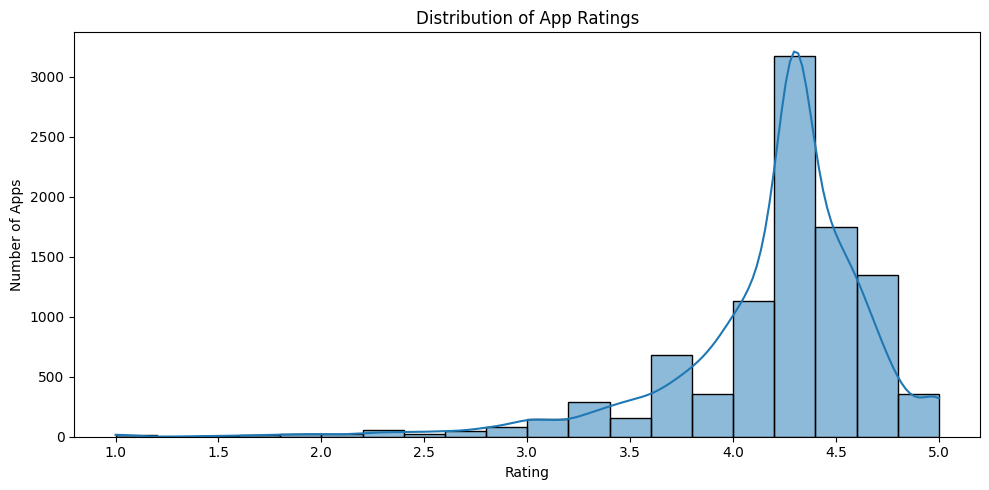

In [24]:
plt.figure(figsize=(10, 5))

sns.histplot(apps_df["Rating"], bins=20, kde=True)

plt.title("Distribution of App Ratings")
plt.xlabel("Rating")
plt.ylabel("Number of Apps")
plt.tight_layout()
plt.show()

In [25]:
avg_rating_category = (
    apps_df.groupby("Category")["Rating"]
    .mean()
    .sort_values(ascending=False)
)

print("Top 10 Categories by Average Rating:")
print(avg_rating_category.head(10))

Top 10 Categories by Average Rating:
Category
EVENTS                 4.395313
EDUCATION              4.363866
ART_AND_DESIGN         4.354687
BOOKS_AND_REFERENCE    4.334234
PERSONALIZATION        4.325532
PARENTING              4.300000
BEAUTY                 4.283019
SOCIAL                 4.255230
HEALTH_AND_FITNESS     4.251736
GAME                   4.249948
Name: Rating, dtype: float64


### Observation

- Most app ratings are concentrated between approximately **4.0 and 4.7**.
- The distribution is strongly concentrated around **4.3–4.4**, indicating generally positive user ratings.
- Very low ratings are relatively uncommon.
- A smaller number of apps have ratings close to **5.0**, representing highly rated applications.

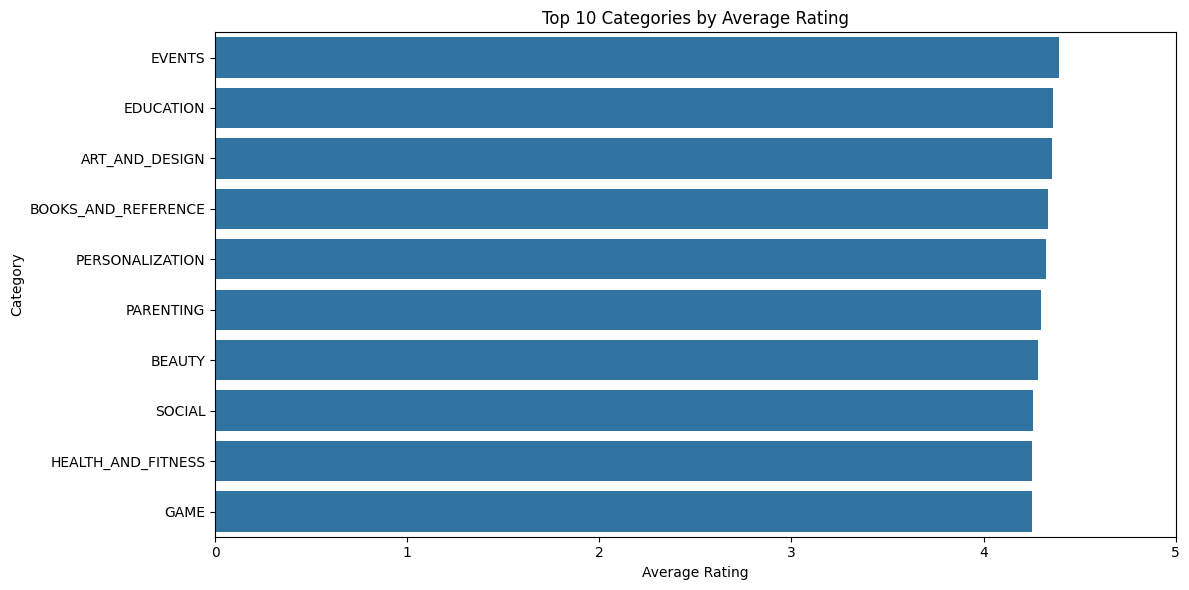

In [26]:
plt.figure(figsize=(12, 6))

sns.barplot(
    x=avg_rating_category.head(10).values,
    y=avg_rating_category.head(10).index
)

plt.title("Top 10 Categories by Average Rating")
plt.xlabel("Average Rating")
plt.ylabel("Category")
plt.xlim(0, 5)
plt.tight_layout()
plt.show()

### Observation

- **EVENTS** has the highest average rating among the top categories.
- **EDUCATION** and **ART_AND_DESIGN** also have relatively high average ratings.
- Most of the top categories have average ratings above **4.2**.
- This suggests that apps in these categories generally receive positive user feedback.

In [ ]:
# Step 7: App Size vs. Installs Analysis

The relationship between app size and the number of installs is analysed using a scatter plot to determine whether larger apps tend to attract more users.

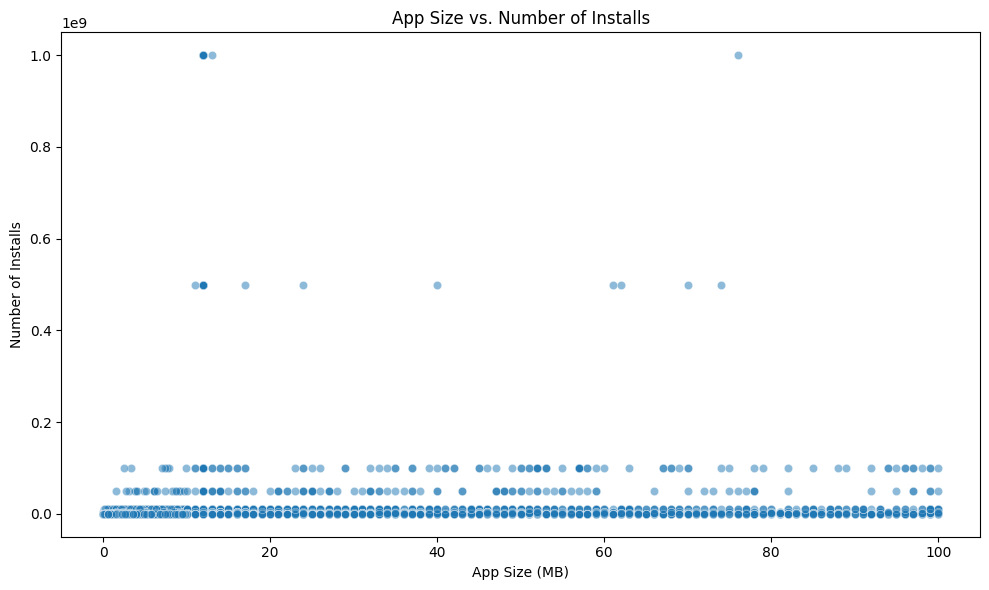

In [27]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=apps_df,
    x="Size",
    y="Installs",
    alpha=0.5
)

plt.title("App Size vs. Number of Installs")
plt.xlabel("App Size (MB)")
plt.ylabel("Number of Installs")
plt.tight_layout()
plt.show()

### Observation

- The scatter plot shows that app size does not have a strong visible relationship with the number of installs.
- Most apps have relatively low install counts regardless of their size.
- A small number of apps have extremely high install counts, creating visible outliers.
- Therefore, app size alone does not appear to be a strong predictor of app popularity.

In [28]:
correlation = apps_df["Size"].corr(apps_df["Installs"])

print("Correlation between App Size and Installs:", correlation)

Correlation between App Size and Installs: 0.03056702054828012


### Observation

- The correlation between app size and installs is approximately **0.03**.
- This indicates a **very weak positive relationship** between app size and the number of installs.
- Therefore, app size alone is not a strong factor in determining an app's popularity.
- The scatter plot also shows several high-install outliers.

# Step 8: Pricing Analysis

The pricing structure of Google Play Store apps is analysed by comparing free and paid applications, examining the price distribution of paid apps, and estimating potential revenue across categories.

Type
Free    8903
Paid     756
Name: count, dtype: int64


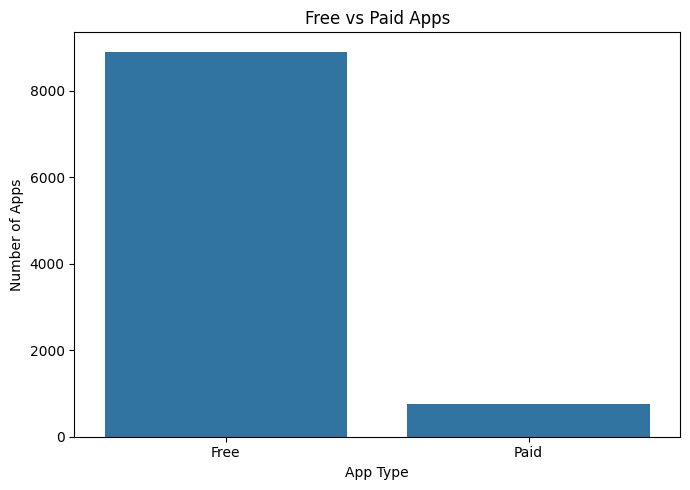

In [30]:
#free  vs oaid
type_counts = apps_df["Type"].value_counts()

print(type_counts)

plt.figure(figsize=(7, 5))

sns.barplot(
    x=type_counts.index,
    y=type_counts.values
)

plt.title("Free vs Paid Apps")
plt.xlabel("App Type")
plt.ylabel("Number of Apps")
plt.tight_layout()
plt.show()

### Observation

- The Google Play Store dataset is strongly dominated by **Free apps**.
- Paid apps represent a much smaller share of the total apps.
- This suggests that the free-with-monetization model is more common than direct paid downloads.
- Developers may need to consider alternative monetization strategies such as advertisements, subscriptions, or in-app purchases.

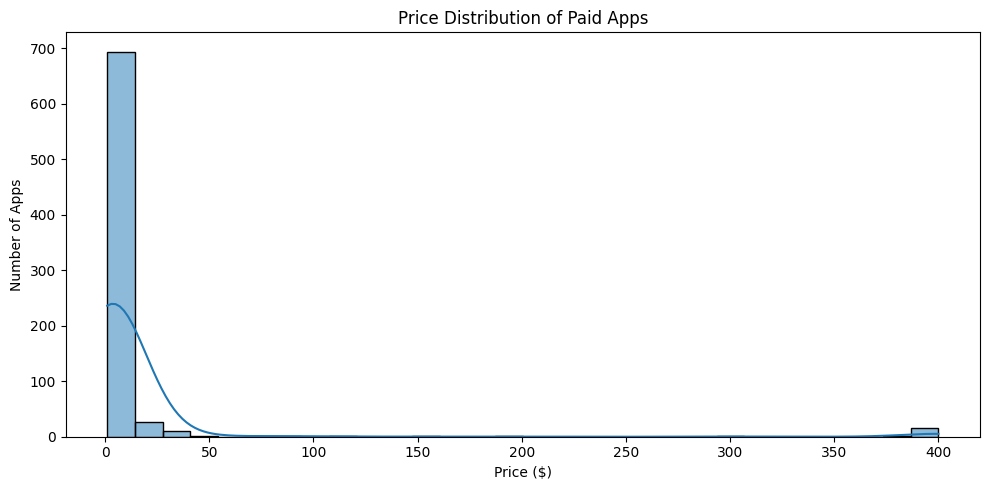

In [31]:
#paid app price distribution
paid_apps = apps_df[apps_df["Type"] == "Paid"]

plt.figure(figsize=(10, 5))

sns.histplot(
    paid_apps["Price"],
    bins=30,
    kde=True
)

plt.title("Price Distribution of Paid Apps")
plt.xlabel("Price ($)")
plt.ylabel("Number of Apps")
plt.tight_layout()
plt.show()

### Observation

- Most paid apps are priced at relatively low values.
- The distribution is strongly right-skewed, with a small number of apps having very high prices.
- Most paid apps are concentrated below approximately $30.
- A few high-priced apps create noticeable outliers, with some prices reaching around $400.

Top 10 Categories by Estimated Revenue:
Category
FAMILY             1.136798e+08
LIFESTYLE          5.758394e+07
GAME               4.068864e+07
FINANCE            2.572668e+07
PHOTOGRAPHY        8.547768e+06
PERSONALIZATION    6.796948e+06
MEDICAL            5.957536e+06
TOOLS              5.464821e+06
SPORTS             4.706212e+06
PRODUCTIVITY       4.313375e+06
Name: Estimated_Revenue, dtype: float64


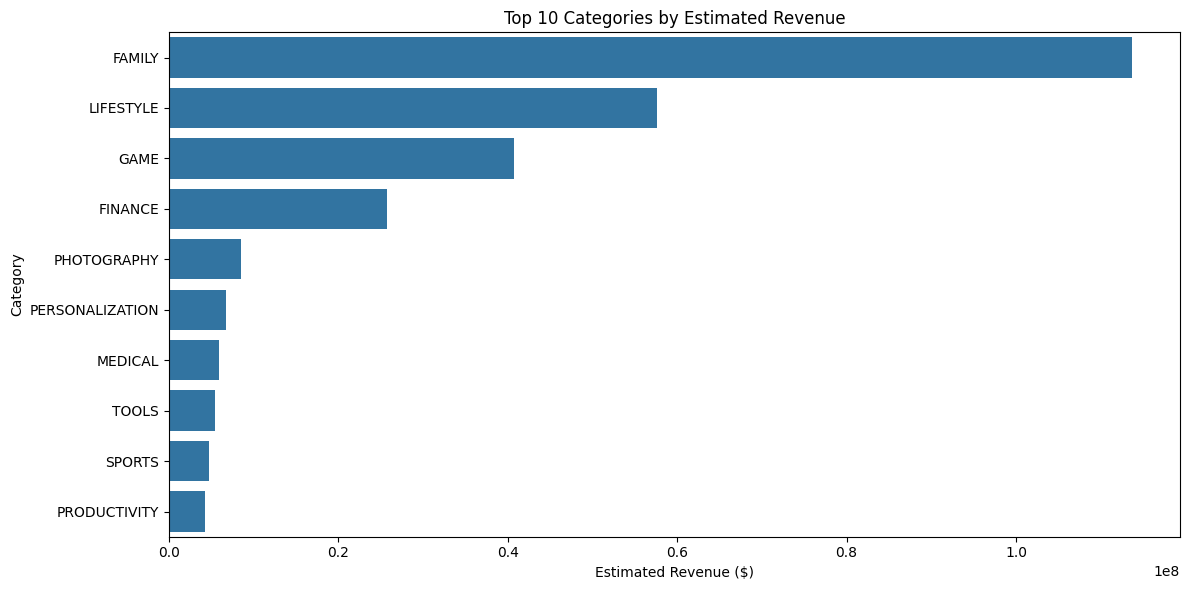

In [34]:

#revenue estimation by category
# Calculate estimated revenue for paid apps
paid_apps = apps_df[apps_df["Type"] == "Paid"].copy()

paid_apps["Estimated_Revenue"] = paid_apps["Price"] * paid_apps["Installs"]

revenue_by_category = (
    paid_apps.groupby("Category")["Estimated_Revenue"]
    .sum()
    .sort_values(ascending=False)
)

print("Top 10 Categories by Estimated Revenue:")
print(revenue_by_category.head(10))

#chart
plt.figure(figsize=(12, 6))

sns.barplot(
    x=revenue_by_category.head(10).values,
    y=revenue_by_category.head(10).index
)

plt.title("Top 10 Categories by Estimated Revenue")
plt.xlabel("Estimated Revenue ($)")
plt.ylabel("Category")
plt.tight_layout()
plt.show()

### Observation

- **FAMILY** generates the highest estimated revenue among the categories analysed.
- **LIFESTYLE** and **GAME** follow as the next highest-revenue categories.
- FINANCE also shows significant estimated revenue compared with most other categories.
- Revenue is highly concentrated in a few categories, suggesting that app demand and pricing can strongly influence potential earnings.

# Step 9: Sentiment Analysis of User Reviews

User reviews are analysed using TextBlob sentiment analysis.

Each review is classified into three sentiment categories:
- Positive
- Negative
- Neutral

                                              review Sentiment
0  Fantastic spot for an even or a quite cocktail...  Positive
1  Love, love, love the calamari. It's so good an...  Positive
2  Love this place. Stiff martinis and cocktails,...  Positive
3  It's everything a great cocktail bar should be...  Positive
4  I came here before a pirates game, so it was a...  Positive
5  Olive or Twist is the historic site of my VERY...  Positive
6  A beautiful little bar with an exciting "marti...  Positive
7  My favorite bar in town love the live music an...  Positive
8  The location is in a strip mall, but this plac...  Positive
9  THIS PLACE IS OPEN!The best food and the best ...  Positive
Sentiment
Positive    3527
Negative     740
Neutral       54
Name: count, dtype: int64


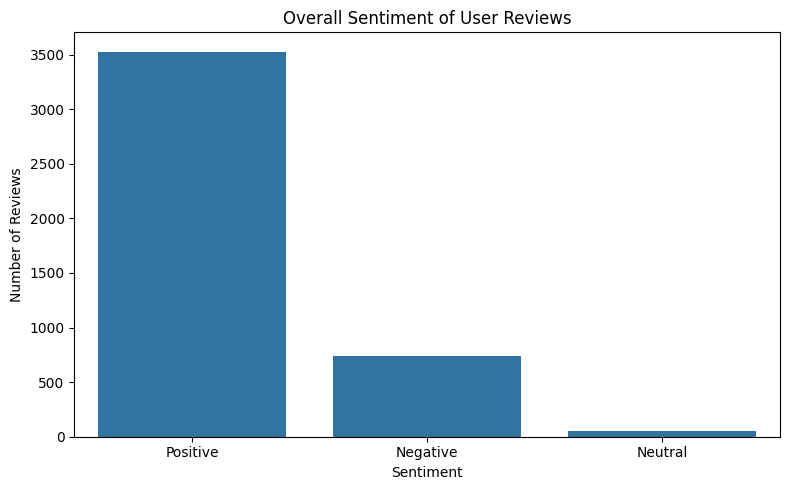

In [37]:
def get_sentiment(review):
    polarity = TextBlob(str(review)).sentiment.polarity

    if polarity > 0:
        return "Positive"
    elif polarity < 0:
        return "Negative"
    else:
        return "Neutral"


reviews_df["Sentiment"] = reviews_df["review"].apply(get_sentiment)

print(reviews_df[["review", "Sentiment"]].head(10))

sentiment_counts = reviews_df["Sentiment"].value_counts()

print(sentiment_counts)

#chart
plt.figure(figsize=(8, 5))

sns.barplot(
    x=sentiment_counts.index,
    y=sentiment_counts.values
)

plt.title("Overall Sentiment of User Reviews")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")
plt.tight_layout()
plt.show()

### Observation

- The majority of user reviews are classified as **Positive**.
- Negative reviews form a much smaller portion of the dataset.
- Neutral reviews are relatively rare.
- Overall, the review dataset indicates predominantly positive user sentiment toward the apps.

# Step 10: Sentiment Analysis Summary

The User Reviews dataset does not contain an app identifier or category column. Therefore, category-level sentiment could not be directly linked with the Apps dataset.

Instead, the overall sentiment distribution is analysed to understand general user feedback.

In [39]:
print(reviews_df.columns.tolist())

['review', 'class', 'Sentiment']


In [40]:
sentiment_percentage = (
    reviews_df["Sentiment"]
    .value_counts(normalize=True) * 100
)

print("Sentiment Percentage:")
print(sentiment_percentage.round(2))

Sentiment Percentage:
Sentiment
Positive    81.62
Negative    17.13
Neutral      1.25
Name: proportion, dtype: float64


# Step 11: Interactive Visualization

An interactive Plotly visualization is created to explore the distribution of apps across different categories.

In [41]:
import plotly.express as px

# Count apps by category
category_counts = apps_df["Category"].value_counts().reset_index()
category_counts.columns = ["Category", "Number_of_Apps"]

# Create interactive chart
fig = px.bar(
    category_counts.head(10),
    x="Number_of_Apps",
    y="Category",
    orientation="h",
    title="Top 10 App Categories by Number of Apps",
    labels={
        "Number_of_Apps": "Number of Apps",
        "Category": "App Category"
    }
)

fig.update_layout(
    yaxis={"categoryorder": "total ascending"}
)

fig.show()

# Conclusion

### 3 Data-Driven Insights

1. **FAMILY** has the highest number of apps and also generates the highest estimated revenue, making it a highly competitive but potentially profitable category.

2. Most apps are **free**, while paid apps represent a much smaller share. This suggests that free apps with monetization strategies such as ads or in-app purchases are common in the Google Play ecosystem.

3. App ratings are generally concentrated around **4.0–4.5**, indicating that most apps receive positive user ratings. However, app size and installs show only a weak relationship, with a correlation of approximately **0.03**.

### Business Recommendation

A developer planning to launch a new app should consider a less saturated niche, focus on maintaining a high-quality user experience, and evaluate the monetization strategy carefully. User feedback and app ratings should also be monitored continuously to improve the product.

### Project Outcome

The analysis transformed raw Google Play Store and user review data into meaningful insights covering app categories, ratings, installations, pricing, revenue potential, and user sentiment using Python-based data analysis and visualization.